
importing libraries




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score , roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

load data

In [4]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df = pd.DataFrame(data)

EDA

In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['SeniorCitizen'].unique()

array([0, 1])

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [11]:
df['Contract'].describe()

,Contract
count,7043
unique,3
top,Month-to-month
freq,3875


In [12]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [13]:
df['PaymentMethod'].describe()

,PaymentMethod
count,7043
unique,4
top,Electronic check
freq,2365


In [14]:
df['MonthlyCharges'].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


<Axes: ylabel='MonthlyCharges'>

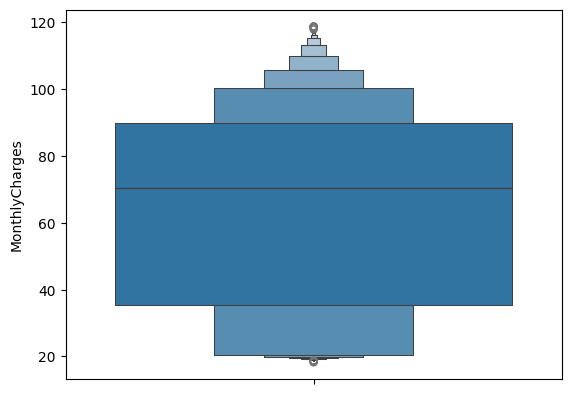

In [15]:
df['MonthlyCharges']=df['MonthlyCharges'].astype(float)
sns.boxenplot(df['MonthlyCharges'])

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()


np.int64(11)

In [17]:
df['TotalCharges'].fillna(0, inplace=True)

/tmp/ipykernel_7312/171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [18]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [19]:
df['Churn'].describe()


,Churn
count,7043
unique,2
top,No
freq,5174


In [20]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


analysis




<Axes: xlabel='TotalCharges', ylabel='Count'>

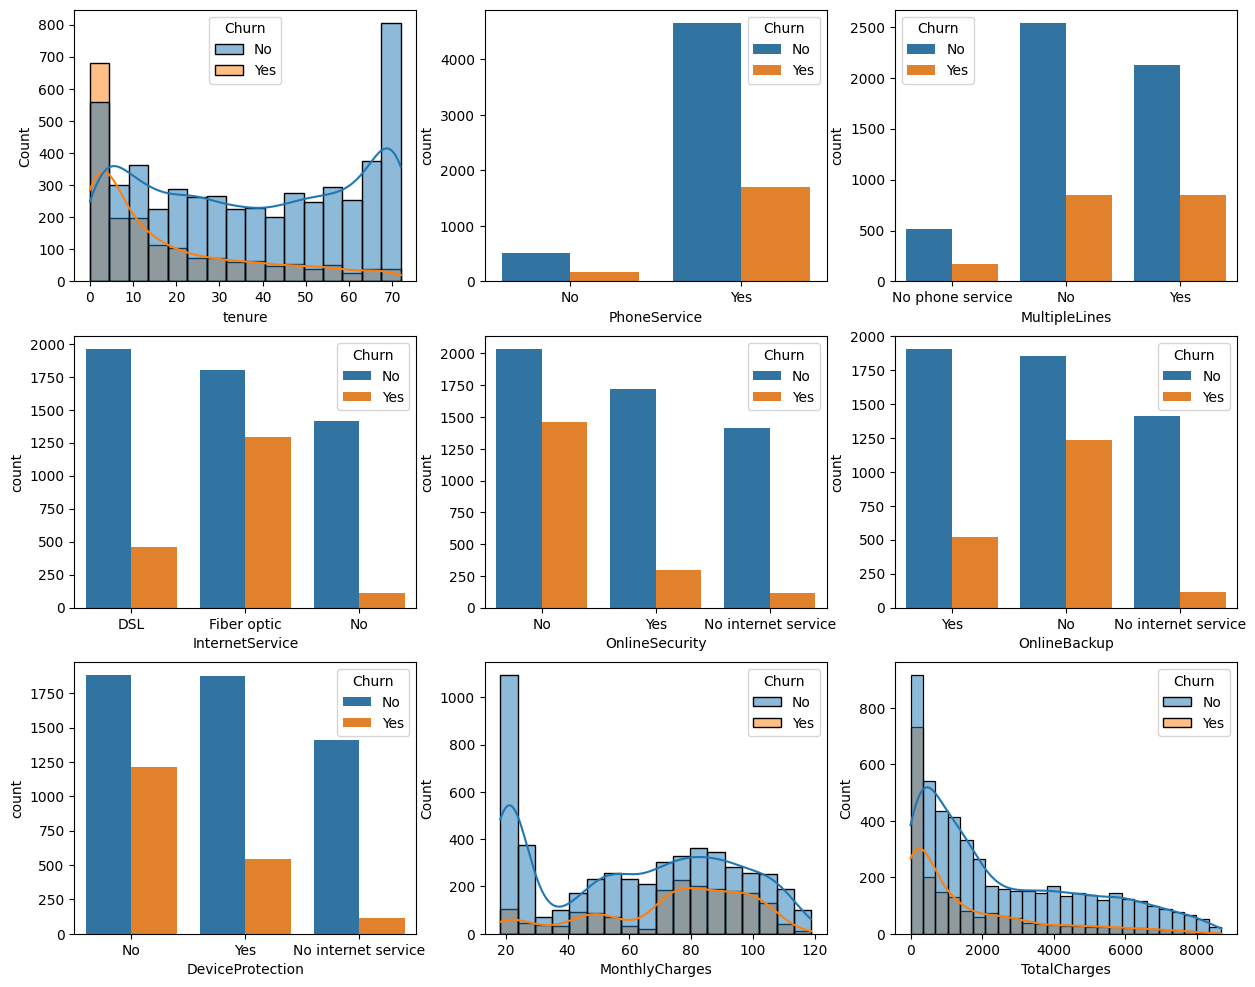

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
sns.histplot(x='tenure',hue='Churn',data=df ,kde=True,ax=axes[0, 0])
sns.countplot(x='PhoneService', hue='Churn', data=df, ax=axes[0, 1])
sns.countplot(x='MultipleLines', hue='Churn', data=df, ax=axes[0, 2])
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1, 0])
sns.countplot(x='OnlineSecurity', hue='Churn', data=df, ax=axes[1, 1])
sns.countplot(x='OnlineBackup', hue='Churn', data=df, ax=axes[1, 2])
sns.countplot(x='DeviceProtection', hue='Churn', data=df, ax=axes[2, 0])
sns.histplot(x='MonthlyCharges', hue='Churn',data=df,kde=True,ax=axes[2, 1])
sns.histplot(x='TotalCharges', hue='Churn',data=df,kde=True,ax=axes[2, 2])

In [22]:
table = pd.crosstab(df['InternetService'], df['Churn'])
print(table)
print((table.loc['Fiber optic','Yes']/(table.loc['Fiber optic','Yes']+table.loc['Fiber optic','No']))*100)

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
41.89276485788114


In [23]:
# 42% of cestomers with fiber optic internet service churned

In [24]:
table_1 = pd.crosstab(df['OnlineSecurity'], df['Churn'])
print(table_1)
print((table_1.loc['No','Yes']/(table_1.loc['No','Yes']+table_1.loc['No','No']))*100)

Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295
41.76672384219554


In [25]:
# 42% of InternetServiceCustomers with no online security churned

In [26]:
table_2 = pd.crosstab(df['OnlineBackup'], df['Churn'])
print(table_2)
print((table_2.loc['No','Yes']/(table_2.loc['No','Yes']+table_2.loc['No','No']))*100)

Churn                  No   Yes
OnlineBackup                   
No                   1855  1233
No internet service  1413   113
Yes                  1906   523
39.92875647668394


In [27]:
# 40% of InternetServiceCustomers with no online backup churned

In [28]:
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsNewCustomer'] = (df['tenure'] < 12).astype(int)
df['HighSpender'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

In [29]:
df.drop('customerID',axis=1,inplace=True)

In [30]:
encoder = LabelEncoder()
df['Churn'] = encoder.fit_transform(df['Churn'])

In [31]:
cat = df.select_dtypes(include='object').columns.to_list()

cat

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [32]:
encoder_2 = OneHotEncoder(sparse_output=False)

for i in cat:
    encoded = encoder_2.fit_transform(df[[i]])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder_2.get_feature_names_out([i]),
        index=df.index
    )
    df = pd.concat([df.drop(columns=[i]), encoded_df], axis=1)

In [33]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgChargesPerMonth,IsNewCustomer,HighSpender,gender_Female,gender_Male,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,1,0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,0,53.985714,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1,36.050000,1,0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,0,40.016304,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,2,70.70,151.65,1,50.550000,1,1,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [34]:
#plt.figure(figsize=(15,15))
#sns.heatmap(df.corr(), annot=True)

preprocessing


In [35]:
x = df.drop('Churn',axis=1)
y = df['Churn']


In [36]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [37]:
scale_list = ['MonthlyCharges','TotalCharges']
scaler = StandardScaler()
x_train[scale_list] = scaler.fit_transform(x_train[scale_list])
x_test[scale_list] = scaler.transform(x_test[scale_list])

In [38]:
model = LogisticRegression(max_iter=1000,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=5)
print("Accuracy for each fold: ", scores)
print("mean accuracy ", scores.mean())

Accuracy for each fold:  [0.82874889 0.81188997 0.80035492 0.79503106 0.79573712]
mean accuracy  0.8063523934556447


In [39]:
model = LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=5)
print("Accuracy for each fold: ", scores)
print("mean accuracy ", scores.mean())

Accuracy for each fold:  [0.77373558 0.76574978 0.76841171 0.74267968 0.72113677]
mean accuracy  0.7543427039516091


In [40]:

models_params = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators':[50,100], 'max_depth':[None,5]}
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators':[50,100], 'learning_rate':[0.05,0.1]}
    },
    'SVM': {
        'model': SVC(),
        'params': {'C':[0.1,1], 'kernel':['linear','rbf']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors':[3,5,7]}
    }
}


results = {}
for name, mp in models_params.items():
    grid = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1')
    grid.fit(x_train,y_train)
    results[name] = {
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_,
        'test_score': accuracy_score(y_test, grid.predict(x_test))
    }


for name, res in results.items():
    print(f"{name}:")
    print("  Best CV Score:", res['best_cv_score'])
    print("  Test Set Score:", res['test_score'])
    print("  Best Params:", res['best_params'])
    print("---------------")

RandomForest:
  Best CV Score: 0.5544033093830534
  Test Set Score: 0.7799858055358411
  Best Params: {'max_depth': None, 'n_estimators': 50}
---------------
GradientBoosting:
  Best CV Score: 0.5827900840386311
  Test Set Score: 0.8055358410220014
  Best Params: {'learning_rate': 0.05, 'n_estimators': 100}
---------------
SVM:
  Best CV Score: 0.5546693295127719
  Test Set Score: 0.7963094393186657
  Best Params: {'C': 1, 'kernel': 'linear'}
---------------
KNN:
  Best CV Score: 0.5543761118154743
  Test Set Score: 0.7743080198722498
  Best Params: {'n_neighbors': 5}
---------------


In [41]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1035
           1       0.58      0.52      0.55       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.77      0.77      1409



In [42]:
y_probs = best_model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print("AUC:", auc)

AUC: 0.7911054276783177


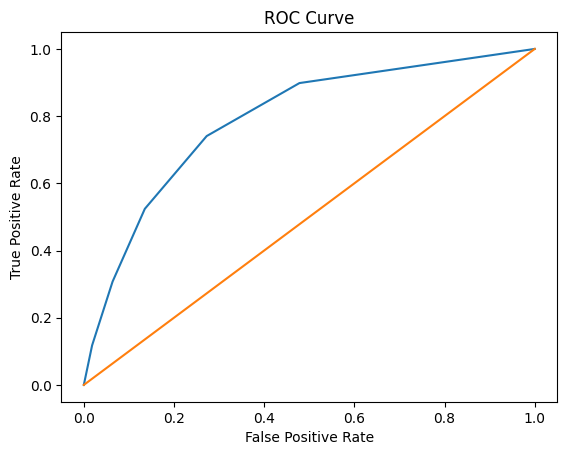

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [44]:
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [45]:
y_train_smote.value_counts()

,count
Churn,
0,4139
1,4139


In [46]:

models_params = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators':[50,100], 'max_depth':[None,5]}
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators':[50,100], 'learning_rate':[0.05,0.1]}
    },
    'SVM': {
        'model': SVC(),
        'params': {'C':[0.1,1], 'kernel':['linear','rbf']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors':[3,5,7]}
    }
}


results = {}
for name, mp in models_params.items():
    grid = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1')
    grid.fit(x_train_smote,y_train_smote)
    results[name] = {
        'best_params': grid.best_params_,
        'best_cv_score': grid.best_score_,
        'test_score': accuracy_score(y_test, grid.predict(x_test))
    }


for name, res in results.items():
    print(f"{name}:")
    print("  Best CV Score:", res['best_cv_score'])
    print("  Test Set Score:", res['test_score'])
    print("  Best Params:", res['best_params'])
    print("---------------")

RandomForest:
  Best CV Score: 0.8264231080759075
  Test Set Score: 0.7693399574166075
  Best Params: {'max_depth': None, 'n_estimators': 100}
---------------
GradientBoosting:
  Best CV Score: 0.8288094708992861
  Test Set Score: 0.7806955287437899
  Best Params: {'learning_rate': 0.1, 'n_estimators': 50}
---------------
SVM:
  Best CV Score: 0.7693893744911529
  Test Set Score: 0.730305180979418
  Best Params: {'C': 1, 'kernel': 'linear'}
---------------
KNN:
  Best CV Score: 0.825475610418767
  Test Set Score: 0.7026259758694109
  Best Params: {'n_neighbors': 3}
---------------


In [47]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.69      0.77      1035
           1       0.46      0.73      0.57       374

    accuracy                           0.70      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.77      0.70      0.72      1409



In [48]:
y_probs = best_model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print("AUC:", auc)

AUC: 0.7529502182954869


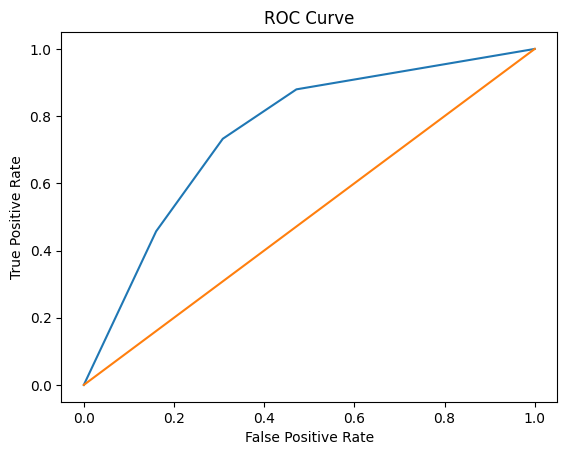

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [50]:

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(x_train_smote, y_train_smote)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [51]:
xgy_pred = model.predict(x_test)
print(classification_report(y_test,xgy_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.61      0.59      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



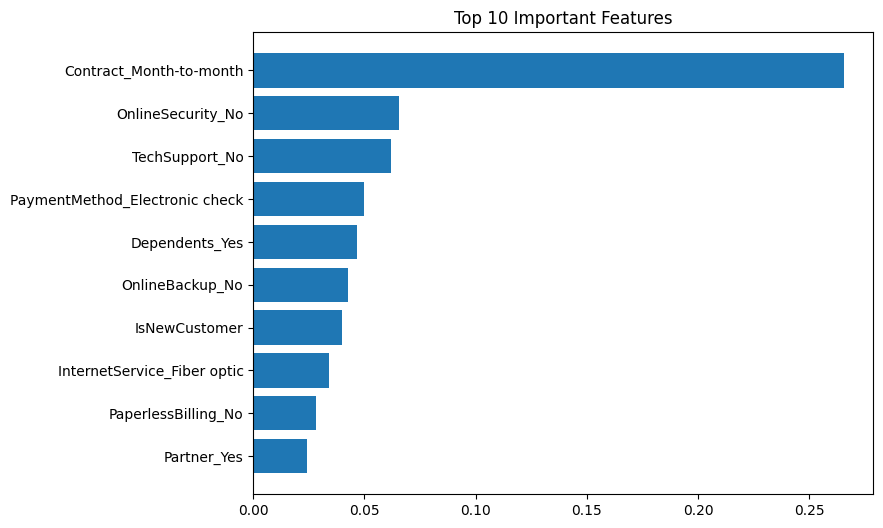

In [53]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), x.columns[indices])
plt.title("Top 10 Important Features")

plt.show()

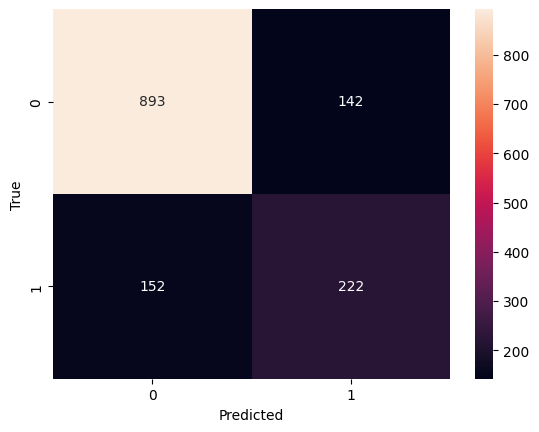

In [55]:
cm = confusion_matrix(y_test,xgy_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [56]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print("AUC:", auc)

AUC: 0.8453021261205405


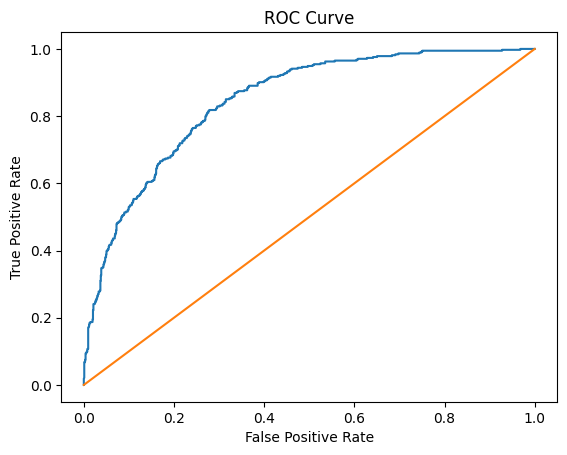

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
